In [1]:
import os, sys
sys.path.append('C:\\_Lib\\python\\slab\\instruments')
sys.path.append('C:\\_Lib\\python') 
sys.path.append('C:\\_Lib\\python\\InstrumentControl\\Devices\\basel')
sys.path.append('C:\\_Lib\\python\\InstrumentControl')
sys.path.append('C:\\_Lib\\python\\InstrumentControl\\Devices\\RF_switch')
sys.path.append('C:\\_Lib\\python\\slab_qick_calib\\analysis')

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output
import time
import pickle
import fitres
import basel
import RC2SP4TA18 as RF_switch
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from SignalCore import SignalCore
import datetime

import RhodeSchwarz
RS = RhodeSchwarz.ZVB8(address='192.168.137.84')
RS.get_id()

Could not load InstrumentManagerWindow
Could not import QickInstrument, try install qick package
Could not load labbrick
Could not load Autonics TM4 Driver
I'm Bat Mouse!


'Rohde-Schwarz,ZNB26-4Port,1334333065100972,3.45\n'

## Config RF switch (Skip if no change needed)

In [18]:
# RF switch 192.168.137.131
# Run 28 config: 
#   - <A0>:  A13| <Acom>: VNA3| <A1>: <Dcom>|
#   - <B0>: <C0>| <Bcom>:   C9| <B1>:   Qick|
#   - <C0>: <B0>| <Ccom>: VNA4| <C1>:    C11|
#   - <D0>:   A9| <Dcom>: <A1>| <D1>:     B1|
# for JPA gain measurement with VNA: A1, B0, C0, D0
# for qick measurement: B1

x = RF_switch.RC2SP4TA18Controller(host='192.168.137.131')
x.connect()

#x.switch('A',0)
x.switch('A',1)

x.switch('B',0)
#x.switch('B',1)

x.switch('C',0)
#x.switch('C',1)

x.switch('D',0)
#x.switch('D',1)

x.disconnect()

KeyboardInterrupt: 

## turn JPA off

In [2]:
# input params
VOLTAGE_MV = 0

# set up basel for biasing
b = basel.Basel(allowed_range_mv=15000)
CH = 12  ## Basal channel

b.set_voltage_mV(CH, voltage_mv=VOLTAGE_MV)
b.enable_output(CH)

# set up signal core for RF output
SC = SignalCore(name='SC',address='100026C4')

params = SC.get_rf_parameters()
print(params.rf1_freq, params.rf_level)

SC.set_output_state(enable=False)
status = SC.get_device_status()
print(status.operate_status.rf1_out_enable)

SC.close_device()

# print when this cell was last run
print("Last run:", datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S"))

Connection OK
 to IP: ('192.168.137.217', 23)
Received: 0

7740000000 -11.0
SC100026C4 : Set output state to False
SC100026C4 : Successfully obtained device status
0
Last run: 2026-05-28 14:20:16


## turn JPA on

In [35]:
SC.close_device()

0

In [7]:
# input params
VOLTAGE_MV = 30.5 #30
POWER_DBM = -10 #-10, 50%
FREQ_HZ = 7740e6


# set up basel for DC biasing
b = basel.Basel(allowed_range_mv=15000)
CH = 12  ## Basal channel

b.set_voltage_mV(CH, voltage_mv=VOLTAGE_MV)
b.enable_output(CH)

# set up signal core for RF output
SC = SignalCore(name='SC',address='100026C4')
  
SC.set_power(POWER_DBM)
SC.set_output_state(enable=True)
SC.set_frequency(FREQ_HZ)

SC.close_device()

# print when this cell was last run
print("Last run:", datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S"))

Connection OK
 to IP: ('192.168.137.217', 23)
Received: 0

SC100026C4 : Set power to -10.00 dBm
SC100026C4 : Set output state to True
SC100026C4 : Set frequency to 7.740000e+09 Hz
Last run: 2026-05-28 14:35:35


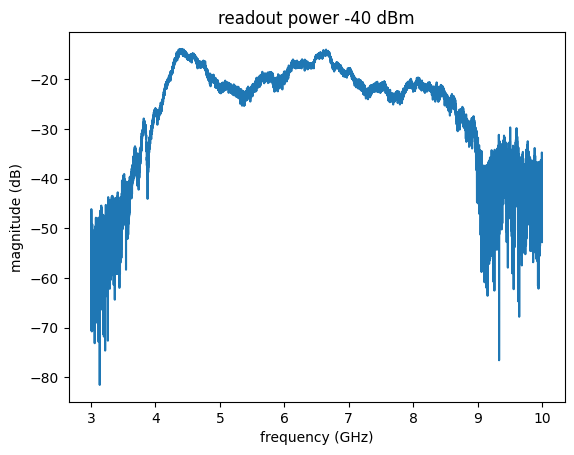

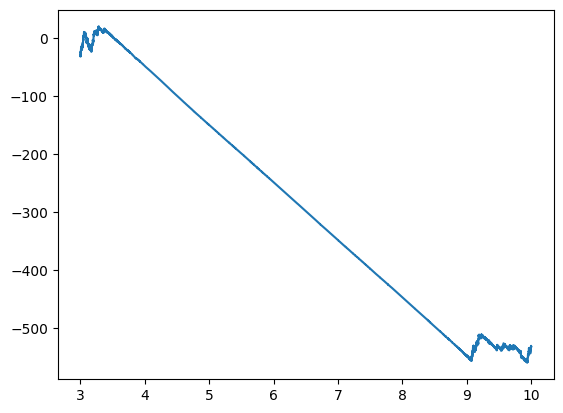

(10001,) (10001,)


In [44]:
num_freqs = 10001

start = 3; stop = 14; step = 12
#start = 7.6; stop = 7.8; step = 0.2



x = RF_switch.RC2SP4TA18Controller(host='192.168.137.132')
x.connect()
channel_dict = {1:'C5', 2:'C6', 3:'C8', 4:'C10'}

for i in range(4):
    x.switch('A',i+1)
    x.switch('B',i+1)
    time.sleep(1)
    current = start

    freq_all = np.array([])
    mag_all = np.array([])
    phase_all = np.array([]) 

    while current <= stop:
            
        RS.reset()
        settings = RS.trans_default_settings()
        settings['measurement'] = 'S21'
        settings['start_freq'] = (current)*1e9
        settings['stop_freq'] = (current + step)*1e9
        settings['RFpower'] = -40
        settings['ifBW'] = 10000
        settings['avg_time'] = 10
        # if RFpower < -30:
        #     settings['avg_time'] = 0.5 * (10 ** (-RFpower/10)) / (10 ** (30/10))  # Increase averaging time for lower powers

        settings['freq_points'] = num_freqs
        data2 = RS.trans_meas(settings)
        mag = np.array(eval(str(data2['mag'])))
        phase = np.array(eval(str(data2['phase'])))
        freq = np.array(eval(str(data2['xaxis'])))/1e9

        freq_all = np.concatenate((freq_all,freq))
        mag_all = np.concatenate((mag_all,mag))
        phase_all = np.concatenate((phase_all,phase))

        phase_all_plot = np.unwrap(phase_all/180*np.pi)
        phase_fit = np.polyfit(freq_all[:1000], phase_all_plot[:1000], 1)
        phase_all_plot = phase_all_plot - np.polyval(phase_fit, freq_all)

        current += step


        clear_output(wait=True)  # clears previous plot in the notebook cell
        print(f'Measured {current-start:.2f} GHz / {stop-start:.2f} GHz', end='\r')
        plt.plot(freq_all, mag_all)
        plt.xlabel('frequency (GHz)')
        plt.ylabel('magnitude (dB)')
        plt.title('readout power {} dBm'.format(settings['RFpower']))

        plt.figure()
        plt.plot(freq_all, phase_all_plot)
        
        plt.show()
        time.sleep(0.1)   
        # res_idx = np.argmin(abs(freq-6.9028))
        # plt.plot(freq_all,mag_all)
        # plt.plot(freq[res_idx],mag[res_idx],'ro')
        # plt.show()
        print(freq_all.shape, mag_all.shape)
    pickle.dump((freq_all, mag_all, phase_all), open(f'C:/_Data/SMPD/2026_03_14/BFG_C{channel_dict[i+1]}.pkl', 'wb'))

## zoom in on waste resonance

In [1]:
num_freqs = 1001

start = 7.72; stop = 7.759; step = 0.04
# start = 7.6; stop = 7.8; step = 0.2

current = start

freq_all = np.array([])
mag_all = np.array([])
phase_all = np.array([]) 

while current <= stop:
        
    RS.reset()
    settings = RS.trans_default_settings()
    settings['measurement'] = 'S43'
    settings['start_freq'] = (current)*1e9
    settings['stop_freq'] = (current + step)*1e9
    settings['RFpower'] = -51
    settings['ifBW'] = 10000
    settings['avg_time'] = 10
    # if RFpower < -30:
    #     settings['avg_time'] = 0.5 * (10 ** (-RFpower/10)) / (10 ** (30/10))  # Increase averaging time for lower powers

    settings['freq_points'] = num_freqs
    data2 = RS.trans_meas(settings)
    mag = np.array(eval(str(data2['mag'])))
    phase = np.array(eval(str(data2['phase'])))
    freq = np.array(eval(str(data2['xaxis'])))/1e9

    freq_all = np.concatenate((freq_all,freq))
    mag_all = np.concatenate((mag_all,mag))
    phase_all = np.concatenate((phase_all,phase))

    phase_all_plot = np.unwrap(phase_all/180*np.pi)
    phase_fit = np.polyfit(freq_all[:num_freqs//10], phase_all_plot[:num_freqs//10], 1)
    phase_all_plot = phase_all_plot - np.polyval(phase_fit, freq_all)

    current += step


    clear_output(wait=True)  # clears previous plot in the notebook cell
    print(f'Measured {current-start:.2f} GHz / {stop-start:.2f} GHz', end='\r')
    plt.plot(freq_all, mag_all)
    plt.xlabel('frequency (GHz)')
    plt.ylabel('magnitude (dB)')
    plt.title('readout power {} dBm'.format(settings['RFpower']))

    plt.figure()
    plt.plot(freq_all, phase_all_plot)
    plt.xlabel('frequency (GHz)')
    plt.ylabel('phase (radians)')
    plt.title('readout power {} dBm'.format(settings['RFpower']))
    
    plt.show()
    time.sleep(0.1)   
    # res_idx = np.argmin(abs(freq-6.9028))
    # plt.plot(freq_all,mag_all)
    # plt.plot(freq[res_idx],mag[res_idx],'ro')
    # plt.show()
    print(freq_all.shape, mag_all.shape)
# pickle.dump((freq_all, mag_all, phase_all), open(f'C:/_Data/SMPD/2026_04_30_JPA/waste.pkl', 'wb'))

NameError: name 'np' is not defined

Resonance frequency: 7.742864 GHz


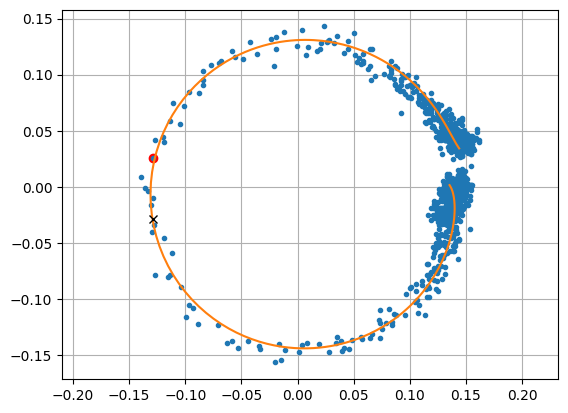

In [3]:
# load data 
freq_all, mag_all, phase_all = pickle.load(open(f'C:/_Data/SMPD/2026_04_30_JPA/waste.pkl', 'rb'))

phase_all_plot = np.unwrap(phase_all/180*np.pi)
phase_fit = np.polyfit(freq_all[:len(freq_all)//10], phase_all_plot[:len(freq_all)//10], 1)
phase_all_plot = phase_all_plot - np.polyval(phase_fit, freq_all)

# convert mag_all and phase_all to complex S21
S21 = 10**(mag_all/20) * np.exp(1j * (phase_all_plot))

# find where the slope of the phase is maximum (approximate resonance frequency)
phase_slope = np.gradient(phase_all_plot, freq_all)
steepest_idx = np.argmax(np.abs(phase_slope))
resonance_freq = freq_all[steepest_idx]

# fit S21 using fitres.finefit
fit_result = fitres.finefit(freq_all, S21, [resonance_freq])
fit_plot = fitres.resfunc3(freq_all, *fit_result[:6])

S21_fit_fr = fitres.resfunc3(fit_result[0], *fit_result[:6])

plt.plot(S21.real, S21.imag, ls='', marker='.')
plt.plot(S21[steepest_idx].real, S21[steepest_idx].imag, 'ro',zorder=-100)
plt.plot(fit_plot.real, fit_plot.imag)
plt.plot(S21_fit_fr.real, S21_fit_fr.imag, 'kx')
plt.gca().set_aspect('equal', adjustable='datalim')
plt.grid(True)

waste_resonance = fit_result[0]

print(f"Resonance frequency: {fit_result[0]:.6f} GHz")

# JPA gain measurement

In [3]:
data_dir = f'C:/_Data/SMPD/2026_04_30_JPA/'
image_dir = f'{data_dir}/images/'
if not os.path.exists(image_dir):
    os.makedirs(image_dir)

## measure waste baseline

Measure the waste resonator with VNA with JPA off. This is to set the baseline for the following gain measurement. **num_freqs, freq range have to be the same as in the gain scans.**

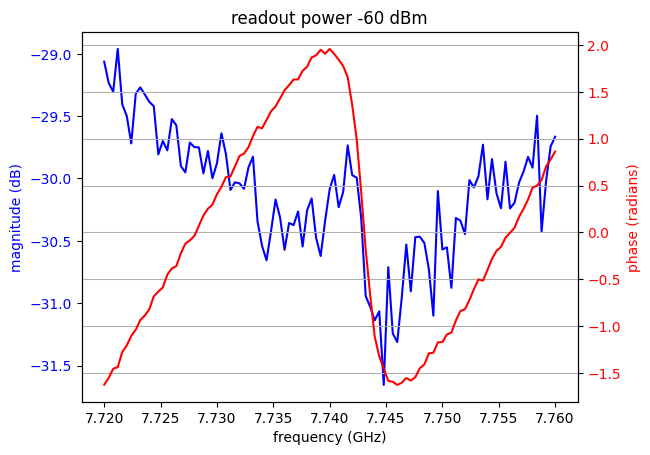

<Figure size 640x480 with 0 Axes>

In [4]:
set_name = f'waste_baseline_0528_run3'
file_name = os.path.join(data_dir, f'{set_name}.pkl')

num_freqs = 101
start = 7.72; stop = 7.759; step = 0.04

current = start

freq_all = np.array([])
mag_all = np.array([])
phase_all = np.array([]) 

while current <= stop:
        
    RS.reset()
    settings = RS.trans_default_settings()
    settings['measurement'] = 'S43'
    settings['start_freq'] = (current)*1e9
    settings['stop_freq'] = (current + step)*1e9
    settings['RFpower'] = -60
    settings['ifBW'] = 10000
    settings['avg_time'] = 50
    # if RFpower < -30:
    #     settings['avg_time'] = 0.5 * (10 ** (-RFpower/10)) / (10 ** (30/10))  # Increase averaging time for lower powers

    settings['freq_points'] = num_freqs
    data2 = RS.trans_meas(settings)
    mag = np.array(eval(str(data2['mag'])))
    phase = np.array(eval(str(data2['phase'])))
    freq = np.array(eval(str(data2['xaxis'])))/1e9

    freq_all = np.concatenate((freq_all,freq))
    mag_all = np.concatenate((mag_all,mag))
    phase_all = np.concatenate((phase_all,phase))

    phase_all_plot = np.unwrap(phase_all/180*np.pi)
    phase_fit = np.polyfit(freq_all[:1000], phase_all_plot[:1000], 1)
    phase_all_plot = phase_all_plot - np.polyval(phase_fit, freq_all)

    current += step

    clear_output(wait=True)  # clears previous plot in the notebook cell
    print(f'Measured {current-start:.2f} GHz / {stop-start:.2f} GHz', end='\r')
    time.sleep(0.1) 

pickle.dump((freq_all, mag_all, phase_all), open(file_name, 'wb'))

## plot mag and phase on the same figure with two y-axes
fig, ax1 = plt.subplots()
ax1.plot(freq_all, mag_all, 'b-')
ax1.set_xlabel('frequency (GHz)')
ax1.set_ylabel('magnitude (dB)', color='b')
ax1.tick_params(axis='y', labelcolor='b')
ax2 = ax1.twinx()
ax2.plot(freq_all, phase_all_plot, 'r-')
ax2.set_ylabel('phase (radians)', color='r')
ax2.tick_params(axis='y', labelcolor='r')
plt.title('readout power {} dBm'.format(settings['RFpower']))
plt.grid(True)
plt.show()
plt.savefig(os.path.join(image_dir, f'{set_name}.png'), dpi=300, bbox_inches='tight')

## scan over pump power and dc bias

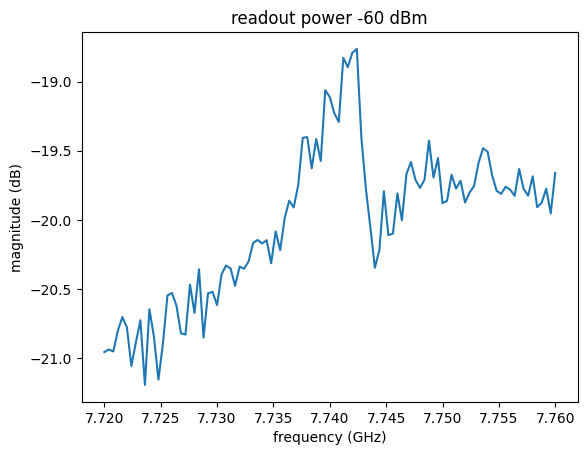

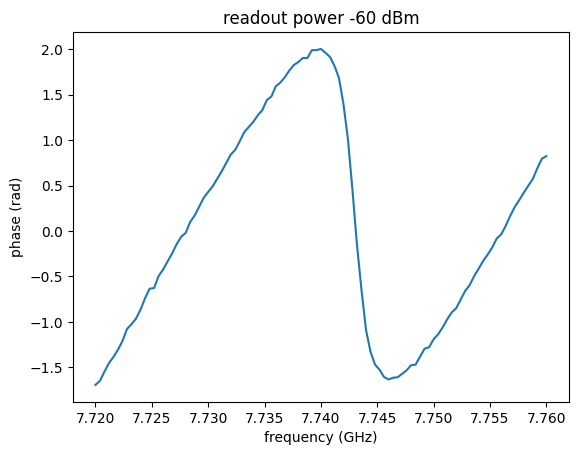

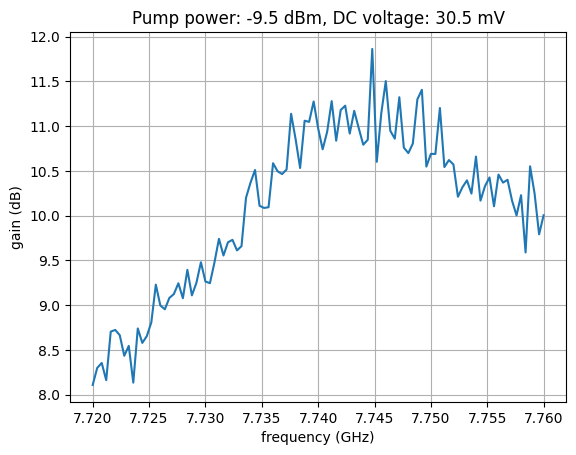

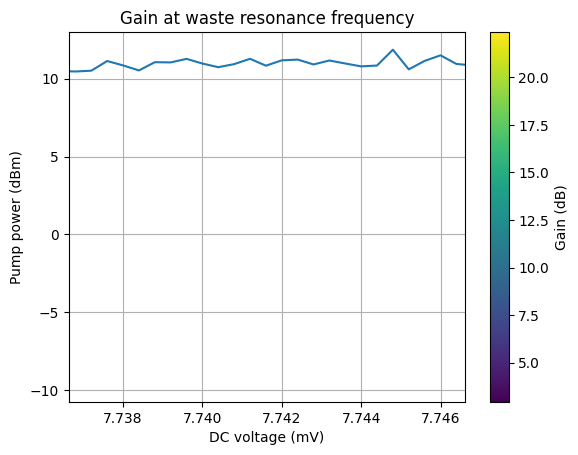

SC100026C4 : Set output state to False


0

In [5]:
num_freqs = 101
waste_resonance = 7.7416254

start = 7.72; stop = 7.759; step = 0.04
# start = 7.6; stop = 7.8; step = 0.2

pump_powers = np.linspace(-10.5,-9.5,3)
#pump_powers = [-9.75]
num_pump_powers = len(pump_powers)
dc_voltages = np.linspace(29.5,30.5,3)
#dc_voltages = [25.5]
num_dc_voltages = len(dc_voltages)

gain_data = np.zeros((num_pump_powers, num_dc_voltages, num_freqs))
SC = SignalCore(name='SC',address='100026C4')

for i, pump_power in enumerate(pump_powers):
    SC.set_power(pump_power)   
    params = SC.get_rf_parameters()
    # print(dir(params))
    print(params.rf1_freq, params.rf_level)

    pump_power_str = f"{params.rf_level:.1f}".replace('.', 'p')

    SC.set_output_state(enable=True)
    # status = SC.get_device_status()
    # print(status.operate_status.rf1_out_enable)

    # store the gain data in a three dimensional array with dimensions (num_pump_powers, num_dc_voltages, num_freqs)





    for j, dc_voltage in enumerate(dc_voltages):
        print('setting DC voltage to {} mV'.format(dc_voltage))
        b.set_voltage_mV(CH, voltage_mv=dc_voltage)
        b.enable_output(CH)    

        freq_all = np.array([])
        mag_all = np.array([])
        phase_all = np.array([]) 

        current = start
        while current <= stop:
                
            RS.reset()
            settings = RS.trans_default_settings()
            settings['measurement'] = 'S43'
            settings['start_freq'] = (current)*1e9
            settings['stop_freq'] = (current + step)*1e9
            settings['RFpower'] = -60
            settings['ifBW'] = 10000
            settings['avg_time'] = 20
            # if RFpower < -30:
            #     settings['avg_time'] = 0.5 * (10 ** (-RFpower/10)) / (10 ** (30/10))  # Increase averaging time for lower powers

            settings['freq_points'] = num_freqs
            data2 = RS.trans_meas(settings)
            mag = np.array(eval(str(data2['mag'])))
            phase = np.array(eval(str(data2['phase'])))
            freq = np.array(eval(str(data2['xaxis'])))/1e9

            freq_all = np.concatenate((freq_all,freq))
            mag_all = np.concatenate((mag_all,mag))
            phase_all = np.concatenate((phase_all,phase))

            phase_all_plot = np.unwrap(phase_all/180*np.pi)
            phase_fit = np.polyfit(freq_all[:1000], phase_all_plot[:1000], 1)
            phase_all_plot = phase_all_plot - np.polyval(phase_fit, freq_all)

            current += step


            # clear_output(wait=True)  # clears previous plot in the notebook cell
            print(f'Measured {current-start:.2f} GHz / {stop-start:.2f} GHz', end='\r')
            plt.figure()
            plt.plot(freq_all, mag_all)
            plt.xlabel('frequency (GHz)')
            plt.ylabel('magnitude (dB)')
            plt.title('readout power {} dBm'.format(settings['RFpower']))

            plt.figure()
            plt.plot(freq_all, phase_all_plot)
            plt.xlabel('frequency (GHz)')
            plt.ylabel('phase (rad)')
            plt.title('readout power {} dBm'.format(settings['RFpower']))

            time.sleep(0.1)   
            # res_idx = np.argmin(abs(freq-6.9028))
            # plt.plot(freq_all,mag_all)
            # plt.plot(freq[res_idx],mag[res_idx],'ro')
            # plt.show()
            print(freq_all.shape, mag_all.shape)


        # pickle.dump((freq_all, mag_all, phase_all), open(f'C:/_Data/SMPD/2026_04_30_JPA/waste_pump_{pump_power_str}_{dc_voltage:.1f}mV.pkl', 'wb'))

        # load waste_baseline.pkl and compute the gain
        freq_baseline, mag_baseline, phase_baseline = pickle.load(open('C:/_Data/SMPD/2026_04_30_JPA/waste_baseline_0528_run3.pkl', 'rb'))
        S21_baseline = 10**(mag_baseline/20) * np.exp(1j * (phase_baseline/180*np.pi))

        S21_pump_on = 10**(mag_all/20) * np.exp(1j * (phase_all/180*np.pi))

        # Compute the gain
        S21_gain = S21_pump_on / S21_baseline

        plt.figure()
        plt.plot(freq_all, 20*np.log10(np.abs(S21_gain)))
        plt.xlabel('frequency (GHz)')
        plt.ylabel('gain (dB)')
        plt.title('Pump power: {:<.1f} dBm, DC voltage: {} mV'.format(pump_power, dc_voltage))
        plt.grid(True)

        plt.figure()
        plt.plot(freq_all, 20*np.log10(np.abs(S21_gain)))
        plt.xlabel('frequency (GHz)')
        plt.ylabel('gain (dB)')
        plt.title('Pump power: {:<.1f} dBm, DC voltage: {} mV'.format(pump_power, dc_voltage))
        plt.xlim(waste_resonance - 0.005, waste_resonance + 0.005)
        plt.grid(True)


        

        gain_data[i, j, :] = 20*np.log10(np.abs(S21_gain))

        # take an average of the gain data in a 0.5 MHz window around the waste resonance frequency
        freq_window = 0.5e6/1e9  # 0.5 MHz

        # Find the indices within the frequency window
        freq_indices = np.where((freq_all >= waste_resonance - freq_window/2) & (freq_all <= waste_resonance + freq_window/2))[0]

        # Compute the average gain within the frequency window
        gain_data_at_resonance = np.mean(gain_data[:,:,freq_indices], axis=2)

        clear_output(wait=True)
        plt.pcolormesh(dc_voltages, pump_powers, gain_data_at_resonance, shading='auto')
        plt.xlabel('DC voltage (mV)')
        plt.ylabel('Pump power (dBm)')
        plt.title('Gain at waste resonance frequency')
        plt.colorbar(label='Gain (dB)')
        plt.show()


pickle.dump((gain_data, pump_powers, dc_voltages), open(f'C:/_Data/SMPD/2026_04_30_JPA/gain_data_0528_run6.pkl', 'wb'))

SC.set_output_state(enable=False)
SC.close_device()

In [5]:
pickle.dump((gain_data, pump_powers, dc_voltages), open(f'C:/_Data/SMPD/2026_04_30_JPA/gain_data_0528_run3.pkl', 'wb'))

7.7416254


Text(0.5, 1.0, 'pump power: -10.5 dBm, DC voltage: 29.5 mV')

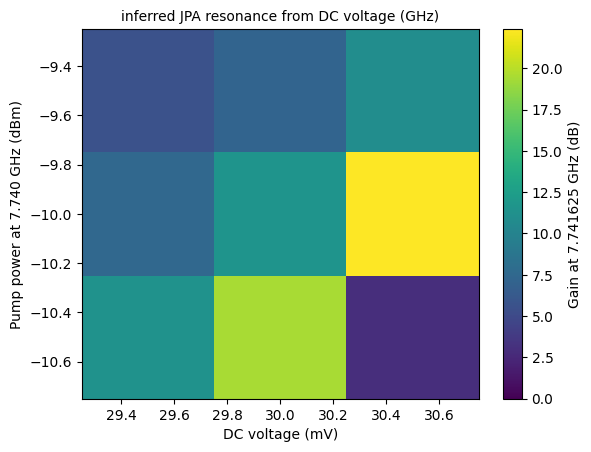

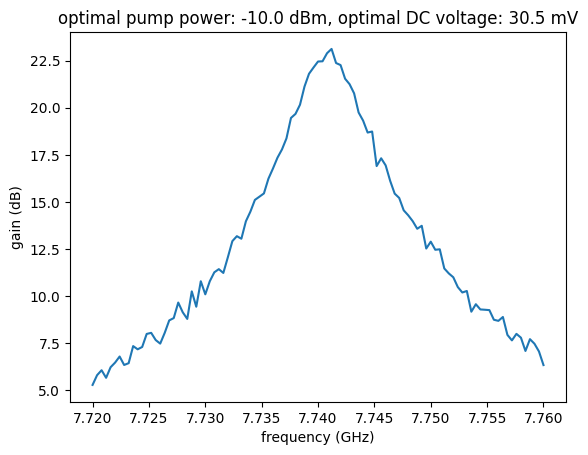

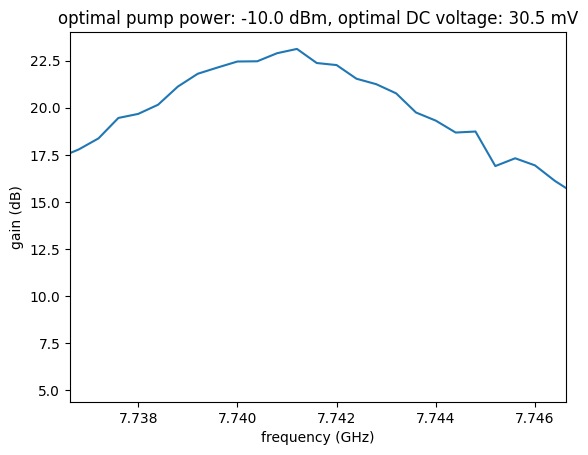

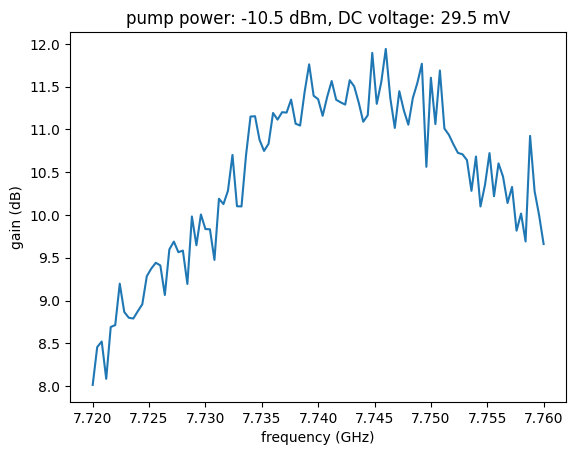

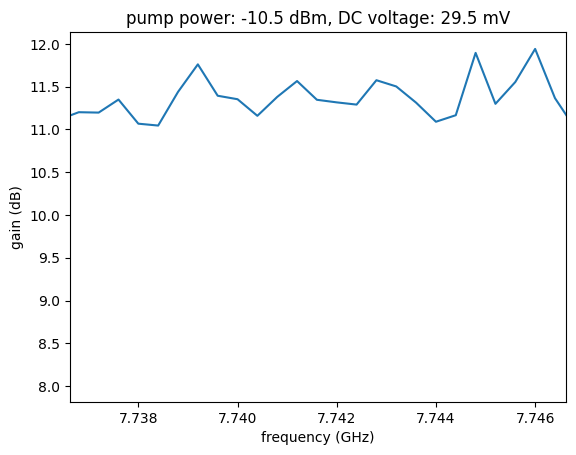

In [6]:
#pump_powers = np.linspace(-15,-9,25)
#dc_voltages = np.linspace(18,28,41)
#pump_powers = np.linspace(-12,-9,5)
#dc_voltages = np.linspace(24,28,5)
#pump_powers = np.linspace(-11.5,-9.5,10)
#dc_voltages = np.linspace(23.5,26.5,10)
freq_all, _, _ = pickle.load(open('C:/_Data/SMPD/2026_04_30_JPA/waste_baseline_0528_run3.pkl', 'rb'))
print(waste_resonance)

# load gain data and plot the gain at the waste resonance frequency as a function of pump power and DC voltage
#gain_data_load = pickle.load(open(f'C:/_Data/SMPD/2026_04_30_JPA/gain_data.pkl', 'rb'))
gain_data_load, pump_powers, dc_voltages = pickle.load(open(f'C:/_Data/SMPD/2026_04_30_JPA/gain_data_0528_run6.pkl', 'rb'))

# take an average of the gain data in a 0.5 MHz window around the waste resonance frequency
freq_window = 0.5e6/1e9  # 0.5 MHz

# Find the indices within the frequency window
freq_indices = np.where((freq_all >= waste_resonance - freq_window/2) & (freq_all <= waste_resonance + freq_window/2))[0]

# Compute the average gain within the frequency window
gain_data_at_resonance = np.mean(gain_data_load[:,:,freq_indices], axis=2)

plt.pcolormesh(dc_voltages, pump_powers, gain_data_at_resonance, shading='auto',vmin=0)
plt.xlabel('DC voltage (mV)')
plt.ylabel('Pump power at 7.740 GHz (dBm)')
plt.title(f'inferred JPA resonance from DC voltage (GHz)',fontsize=10)
plt.colorbar(label=f'Gain at {waste_resonance:.6f} GHz (dB)')

#plt.xlim(24, 28)
#plt.ylim(-12, -9)

# put tick marks at the top that correspond to the JPA frequency at each pump power, which can be computed using the fit result from the waste resonance frequency and the pump power
# the JPA frequency can just be interpolated from dc_powers and frs
# get current xticks
xticks = plt.gca().get_xticks()
xticks = xticks[1:-1]
ticks_desired = [7.75, 7.8, 7.85]
#tick_idcs = np.linspace(1, len(dc_powers),6)
#jpa_frequencies = np.interp(xticks, dc_powers, frs)
#tick_locations = np.interp(ticks_desired, jpa_frequencies, tick_idcs)

# print(jpa_frequencies)
#print(tick_locations)
# put tick marks at the top at the same location as the bottom xticks
# plt.gca().twiny().set_xticks(tick_locations,labels=ticks_desired)
# y().set_xlabel('JPA resonance (GHz)')
# plt.gca().twiny().set_xticklabels(ticks_desired)
# plt.gca().twiny().set_xlabel('JPA frequency (GHz)')

# find the maximum gain and the corresponding pump power and DC voltage
max_gain = np.max(gain_data_at_resonance)
max_gain_idx = np.unravel_index(np.argmax(gain_data_at_resonance), gain_data_at_resonance.shape)
optimal_pump_power = pump_powers[max_gain_idx[0]]
optimal_dc_voltage = dc_voltages[max_gain_idx[1]]
plt.figure()
plt.plot(freq_all, gain_data_load[max_gain_idx[0], max_gain_idx[1], :])
plt.xlabel('frequency (GHz)')
plt.ylabel('gain (dB)')
plt.title('optimal pump power: {:<.1f} dBm, optimal DC voltage: {} mV'.format(optimal_pump_power, optimal_dc_voltage))

plt.figure()
plt.plot(freq_all, gain_data_load[max_gain_idx[0], max_gain_idx[1], :])
plt.xlim(waste_resonance - 0.005, waste_resonance + 0.005)
plt.xlabel('frequency (GHz)')
plt.ylabel('gain (dB)')
plt.title('optimal pump power: {:<.1f} dBm, optimal DC voltage: {} mV'.format(optimal_pump_power, optimal_dc_voltage))

# also show the gain at -11.5 dBm pump power and 25 mV DC voltage
pump_power_11_5_idx = np.argmin(np.abs(pump_powers - (-11.5)))
dc_voltage_25_idx = np.argmin(np.abs(dc_voltages - 25))
plt.figure()
plt.plot(freq_all, gain_data_load[pump_power_11_5_idx, dc_voltage_25_idx, :])
# plt.xlim(waste_resonance - 0.005, waste_resonance + 0.005)
plt.xlabel('frequency (GHz)')
plt.ylabel('gain (dB)')
plt.title('pump power: {:<.1f} dBm, DC voltage: {} mV'.format(pump_powers[pump_power_11_5_idx], dc_voltages[dc_voltage_25_idx]))


plt.figure()
plt.plot(freq_all, gain_data_load[pump_power_11_5_idx, dc_voltage_25_idx, :])
plt.xlim(waste_resonance - 0.005, waste_resonance + 0.005)
plt.xlabel('frequency (GHz)')
plt.ylabel('gain (dB)')
plt.title('pump power: {:<.1f} dBm, DC voltage: {} mV'.format(pump_powers[pump_power_11_5_idx], dc_voltages[dc_voltage_25_idx]))


In [31]:
print(np.shape(dc_voltages))
print(np.shape(pump_powers))
print(np.shape(gain_data_at_resonance))

(1,)
(1,)
(25, 41)


BFG_C10.pkl
BFG_C11.pkl
BFG_C5.pkl
BFG_C6.pkl
BFG_C8.pkl


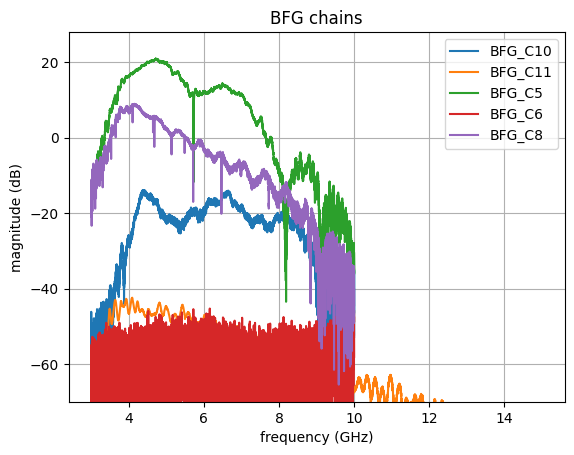

In [47]:
data_dir = 'C:/_Data/SMPD/2026_03_14'
for file in os.listdir(data_dir):
    if file.endswith('.pkl') and file.startswith('BFG'):
        print(file)
        freq_all, mag_all, phase_all = pickle.load(open(os.path.join(data_dir, file), 'rb'))
        plt.plot(freq_all, mag_all,label=file.split('/')[-1].split('.')[0])
        
plt.xlabel('frequency (GHz)')
plt.ylabel('magnitude (dB)')
plt.title('BFG chains')
plt.legend()
plt.ylim(bottom=-70)
# plt.xlim(left=6.5,right=8)
plt.grid(True)

C10_circulator_to_output.pkl
C11_circulator_to_output.pkl
C5_circulator_to_output.pkl
C6_circulator_to_output.pkl
C8_circulator_to_output.pkl
C9_circulator_to_output.pkl


(-100.0, 54.80822177935)

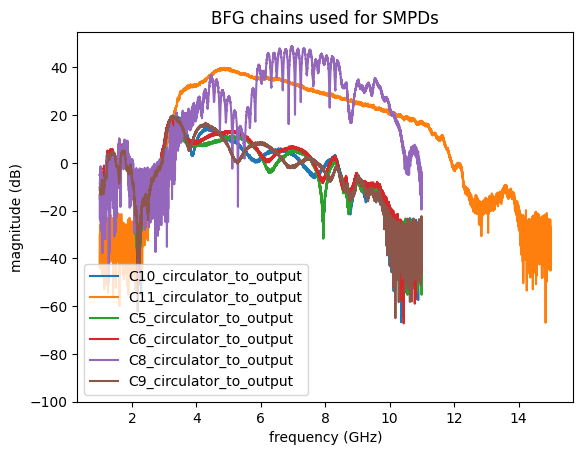

In [140]:
data_dir = 'C:/_Data/SMPD/2026_02_06/circulator_reflection_port'
for file in os.listdir(data_dir):
    if file.endswith('.pkl') :
        print(file)
        freq_all, mag_all, phase_all = pickle.load(open(os.path.join(data_dir, file), 'rb'))
        plt.plot(freq_all, mag_all,label=file.split('/')[-1].split('.')[0])
        
plt.xlabel('frequency (GHz)')
plt.ylabel('magnitude (dB)')
plt.title('BFG chains used for SMPDs')
plt.legend()
plt.ylim(bottom=-100)

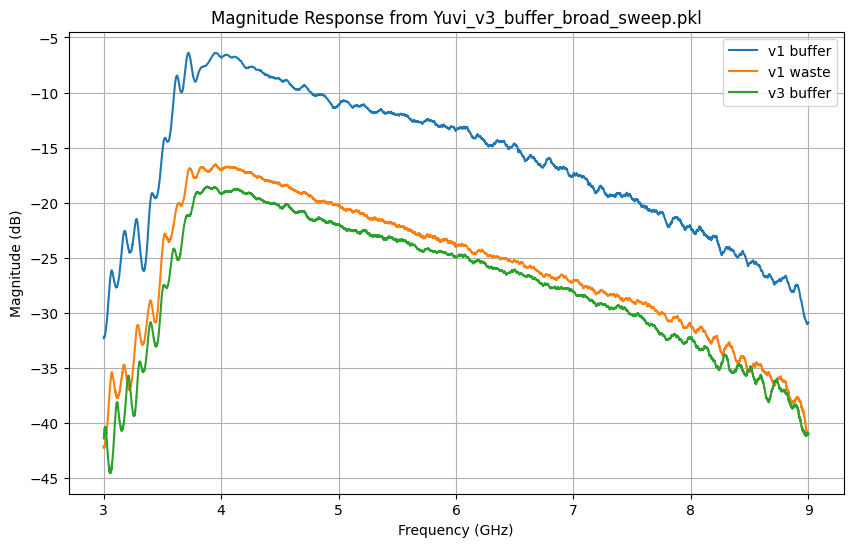

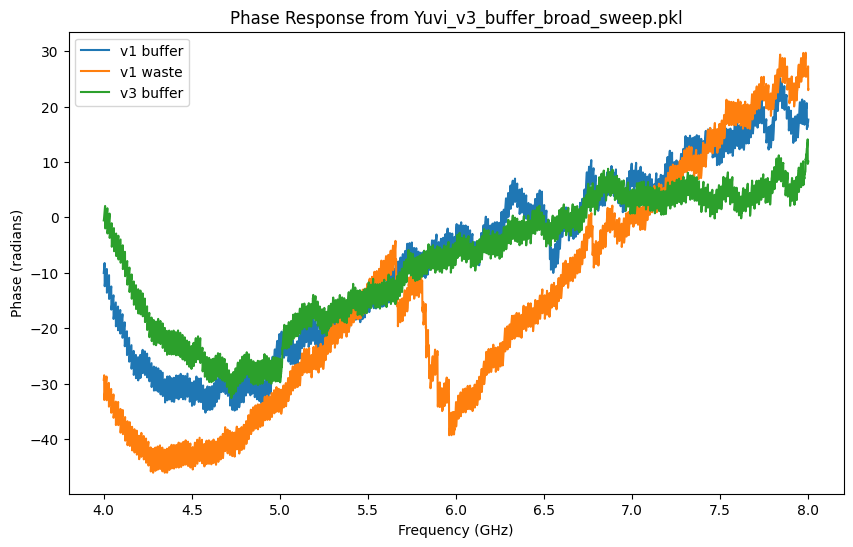

In [34]:
data_dir = 'C:/_Data/SMPD/2026_01_16/'
fig1,ax1 = plt.subplots(figsize=(10,6), num=1)
fig2,ax2 = plt.subplots(figsize=(10,6), num=2)
for file in os.listdir(data_dir):
    if file.endswith('.pkl') and not 'v3_waste' in file:
        file_id = file.split('_')[1] +' ' + file.split('_')[2]
        freq_all, mag_all, phase_all = pickle.load(open(os.path.join(data_dir, file), 'rb'))
        # plt.figure(num=1)
        ax1.plot(freq_all, mag_all,label=file_id)
        ax1.set_xlabel('Frequency (GHz)')
        ax1.set_ylabel('Magnitude (dB)')
        ax1.set_title(f'Magnitude Response from {file}')
        ax1.legend()
        ax1.grid(True)
    
        # plt.figure(num=2)
        phase_all_plot = np.unwrap(phase_all)
        phase_fit = np.polyfit(freq_all, phase_all_plot, 1)
        phase_all_plot = phase_all_plot - np.polyval(phase_fit, freq_all)
        freq_conditional = (freq_all>4)&(freq_all<8)
        ax2.plot(freq_all[freq_conditional], phase_all_plot[freq_conditional],label=file_id)
        ax2.set_xlabel('Frequency (GHz)')
        ax2.set_ylabel('Phase (radians)')
        ax2.set_title(f'Phase Response from {file}')
        ax2.legend()
        # plt.tight_layout()
        # plt.show()

## DC bias scan

In [25]:
num_freqs = 10001
num_dc_powers = 41

freq_array = np.zeros((num_dc_powers, num_freqs))
mag_array = np.zeros((num_dc_powers, num_freqs))
phase_array = np.zeros((num_dc_powers, num_freqs))

dc_powers = np.linspace(-0,40,num_dc_powers)
for i, dc_power in enumerate(dc_powers):
    print('set DC power to {} mV'.format(dc_power))
    b.set_voltage_mV(CH,dc_power)
    b.enable_output(CH)
    time.sleep(0.1)
    start = 7 ; stop = 8.19; step = 1.2   
    #start = 7.6; stop = 7.8; step = 0.2

    current = start
    freq_all = np.array([])
    mag_all = np.array([])
    phase_all = np.array([]) 


    while current < stop:
            
        RS.reset()
        settings = RS.trans_default_settings()
        settings['measurement'] = 'S21'
        settings['start_freq'] = (current)*1e9
        settings['stop_freq'] = (current + step)*1e9
        settings['RFpower'] = -40
        settings['ifBW'] = 10000
        settings['avg_time'] = 5
        # if RFpower < -30:
        #     settings['avg_time'] = 0.5 * (10 ** (-RFpower/10)) / (10 ** (30/10))  # Increase averaging time for lower powers

        settings['freq_points'] = 10001
        data2 = RS.trans_meas(settings)
        mag = np.array(eval(str(data2['mag'])))
        phase = np.array(eval(str(data2['phase'])))
        freq = np.array(eval(str(data2['xaxis'])))/1e9

        freq_all = np.concatenate((freq_all,freq))
        mag_all = np.concatenate((mag_all,mag))
        phase_all = np.concatenate((phase_all,phase))

        phase_all_plot = np.unwrap(phase_all/180*np.pi)
        phase_fit = np.polyfit(freq_all[:1000], phase_all_plot[:1000], 1)
        phase_all_plot = phase_all_plot - np.polyval(phase_fit, freq_all)

        current += step


        clear_output(wait=True)  # clears previous plot in the notebook cell
        print(f'Measured {current-start:.2f} GHz / {stop-start:.2f} GHz', end='\r')
        plt.plot(freq_all, mag_all)
        plt.xlabel('frequency (GHz)')
        plt.ylabel('magnitude (dB)')
        plt.title('readout power {} dBm'.format(settings['RFpower']))

        plt.figure()
        plt.plot(freq_all, phase_all_plot)
        
        plt.show()
        time.sleep(0.1)   
        # res_idx = np.argmin(abs(freq-6.9028))
        # plt.plot(freq_all,mag_all)
        # plt.plot(freq[res_idx],mag[res_idx],'ro')
        # plt.show()
    
    freq_array[i,:] = freq_all
    mag_array[i,:] = mag_all
    phase_array[i,:] = phase_all_plot

b.set_voltage_mV(CH, 0)
b.disable_output(CH)

# pickle.dump((freq_array, mag_array, phase_array, dc_powers), open('C:/_Data/SMPD/2026_04_30_JPA/JPA_dc_sweep_zoom.pkl', 'wb'))


set DC power to 0.0 mV


NameError: name 'RS' is not defined

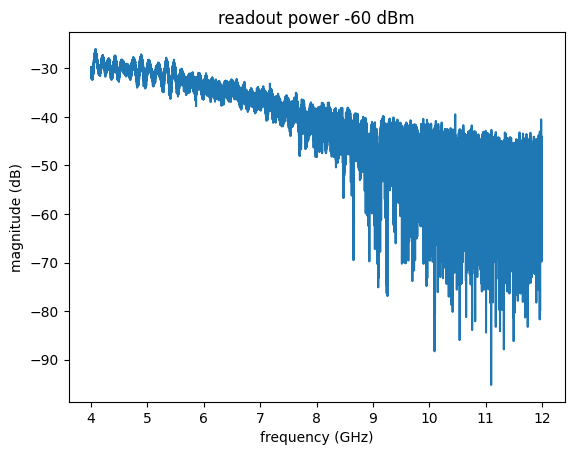

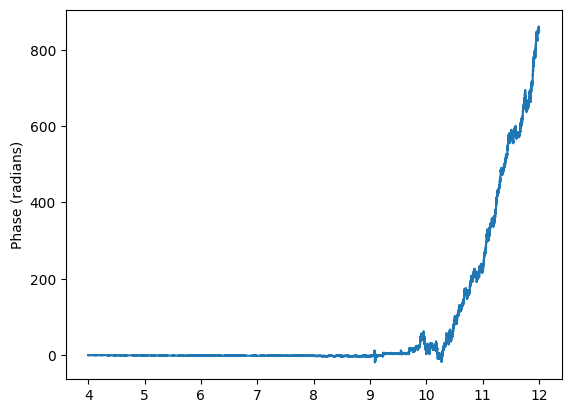

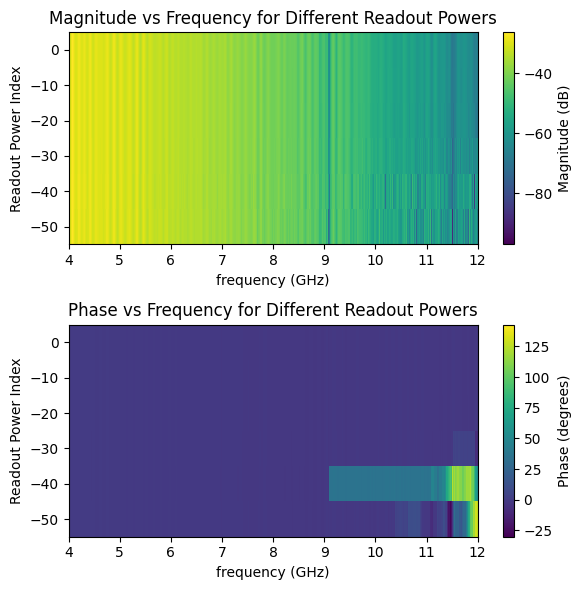

In [92]:
num_freqs = 10001*4

start = 4; stop = 11; step = 2
#start = 7.6; stop = 7.8; step = 0.2


current = start

#initialize array to store data over readout powers


RFpowers=   [0,-10,-20,-30, -40, -50, -60]

mag_pow_sweep = np.zeros((len(RFpowers), num_freqs))
phase_pow_sweep = np.zeros((len(RFpowers), num_freqs))
freq_pow_sweep = np.zeros((len(RFpowers), num_freqs))

# sweep over readout power
for iRFpower, RFpower in enumerate(RFpowers):

    freq_all = np.array([])
    mag_all = np.array([])
    phase_all = np.array([]) 

    while current <= stop:
            
        RS.reset()
        settings = RS.trans_default_settings()
        settings['measurement'] = 'S43'
        settings['start_freq'] = (current)*1e9
        settings['stop_freq'] = (current + step)*1e9
        settings['RFpower'] = RFpower
        settings['ifBW'] = 10000
        settings['avg_time'] = 50
        if RFpower < -40:
            settings['avg_time'] = 500
        # if RFpower < -30:
        #     settings['avg_time'] = 0.5 * (10 ** (-RFpower/10)) / (10 ** (30/10))  # Increase averaging time for lower powers

        settings['freq_points'] = 10001
        data2 = RS.trans_meas(settings)
        mag = np.array(eval(str(data2['mag'])))
        phase = np.array(eval(str(data2['phase'])))
        freq = np.array(eval(str(data2['xaxis'])))/1e9

        freq_all = np.concatenate((freq_all,freq))
        mag_all = np.concatenate((mag_all,mag))
        phase_all = np.concatenate((phase_all,phase))

        phase_all_plot = np.unwrap(phase_all/180*np.pi)
        phase_fit = np.polyfit(freq_all[:1000], phase_all_plot[:1000], 1)
        phase_all_plot = phase_all_plot - np.polyval(phase_fit, freq_all)

        current += step


        clear_output(wait=True)  # clears previous plot in the notebook cell
        print(f'Measured {current-start:.2f} GHz / {stop-start:.2f} GHz', end='\r')
        plt.plot(freq_all, mag_all)
        plt.xlabel('frequency (GHz)')
        plt.ylabel('magnitude (dB)')
        plt.title('readout power {} dBm'.format(settings['RFpower']))

        plt.figure()
        plt.plot(freq_all, phase_all_plot)
        plt.ylabel('Phase (radians)')
        plt.show()
        time.sleep(0.1)   
        # res_idx = np.argmin(abs(freq-6.9028))
        # plt.plot(freq_all,mag_all)
        # plt.plot(freq[res_idx],mag[res_idx],'ro')
        # plt.show()
    freq_pow_sweep[ iRFpower,:] = freq_all
    mag_pow_sweep[ iRFpower,:] = mag_all
    phase_pow_sweep[ iRFpower,:] = phase_all_plot
    
    current = start

# plot phase and magnitude vs frequency for all powers
plt.figure(figsize=(6, 6))
plt.subplot(2, 1, 1)
plt.pcolormesh(freq_pow_sweep[0,:], RFpowers[:-1], mag_pow_sweep[:-1,:], shading='auto')
plt.colorbar(label='Magnitude (dB)')
plt.ylabel('Readout Power Index')
plt.title('Magnitude vs Frequency for Different Readout Powers')
plt.xlabel('frequency (GHz)')

plt.subplot(2, 1, 2)
plt.pcolormesh(freq_pow_sweep[0,:], RFpowers[:-1], phase_pow_sweep[:-1,:], shading='auto')
plt.colorbar(label='Phase (degrees)')
plt.ylabel('Readout Power Index')
plt.title('Phase vs Frequency for Different Readout Powers')
plt.xlabel('frequency (GHz)')
plt.tight_layout()


pickle.dump((freq_pow_sweep, mag_pow_sweep, phase_pow_sweep,RFpowers), open(f'C:\\_Data\\SMPD\\2026_04_02_v3_buffer_search\\Yuvi_v3_buffer_power_sweep.pkl', 'wb'))

In [29]:
pickle.dump((freq_array, mag_array, phase_array), open('C:/_Data/SMPD/2026_03_14/Yuvi_v3_buffer_dc_sweep.pkl', 'wb'))

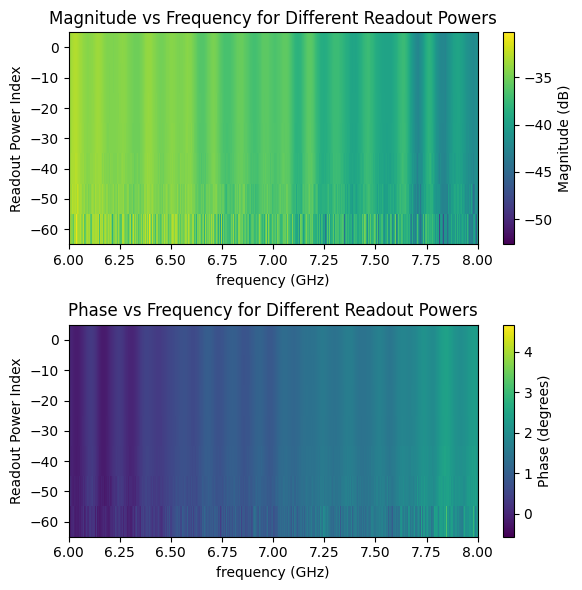

In [91]:
plt.figure(figsize=(6, 6))
plt.subplot(2, 1, 1)
plt.pcolormesh(freq_pow_sweep[0,:], RFpowers, mag_pow_sweep, shading='auto')
plt.colorbar(label='Magnitude (dB)')
plt.ylabel('Readout Power Index')
plt.title('Magnitude vs Frequency for Different Readout Powers')
plt.xlabel('frequency (GHz)')

plt.subplot(2, 1, 2)
plt.pcolormesh(freq_pow_sweep[0,:], RFpowers, phase_pow_sweep, shading='auto')
plt.colorbar(label='Phase (degrees)')
plt.ylabel('Readout Power Index')
plt.title('Phase vs Frequency for Different Readout Powers')
plt.xlabel('frequency (GHz)')
plt.tight_layout()

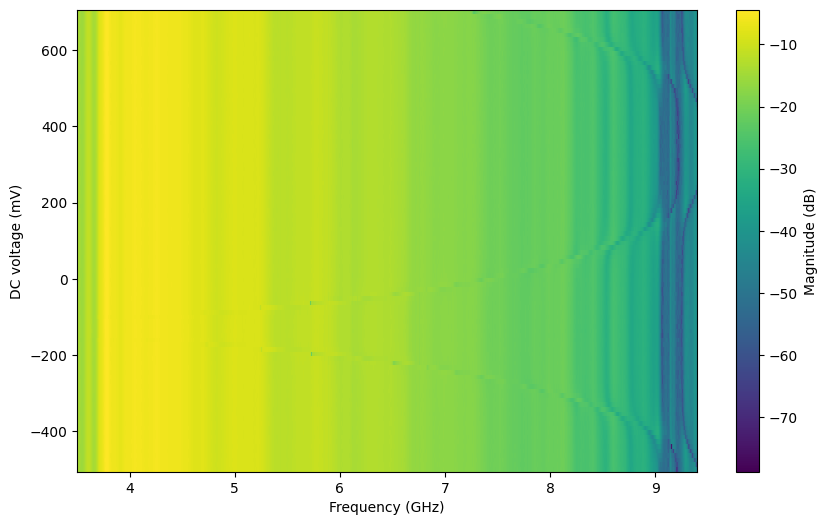

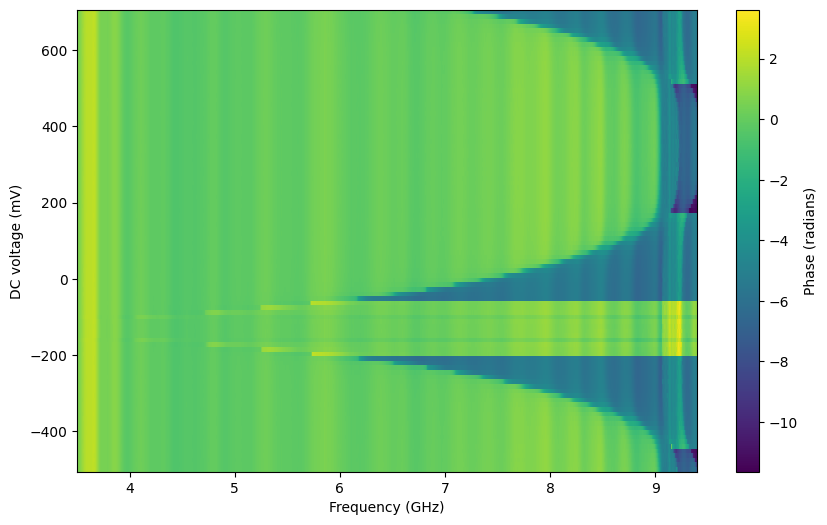

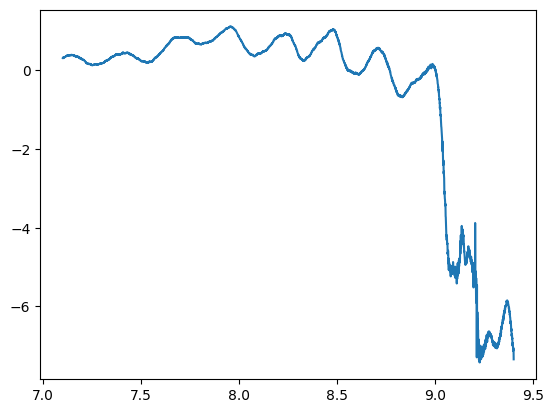

In [65]:
# load data from the pickle file
freq_array, mag_array, phase_array = pickle.load(open('C:/_Data/SMPD/2026_04_30_JPA/JPA_dc_sweep.pkl', 'rb'))
num_dc_powers = len(freq_array)

# compute the slope of the phase response at 200 mV and from 5 to 7 GHz, then subtract it from the phase response at all DC powers
dc_power_200mV_idx = np.argmin(abs(np.linspace(-500,700,num_dc_powers)-200))
freq_zone = (freq_array[dc_power_200mV_idx,:]>5)&(freq_array[dc_power_200mV_idx,:]<7)
phase_fit = np.polyfit(freq_array[dc_power_200mV_idx,:][freq_zone], phase_array[dc_power_200mV_idx,:][freq_zone], 1)
phase_array = phase_array - np.polyval(phase_fit, freq_array)

# make a heatmap of the magnitude response as a function of frequency and DC power
plt.figure(figsize=(10,6)) 
plt.pcolormesh(freq_array[0,:], np.linspace(-500,700,num_dc_powers), mag_array[:,:], shading='auto')
plt.colorbar(label='Magnitude (dB)')
plt.ylabel('DC voltage (mV)')
plt.xlabel('Frequency (GHz)')

plt.figure(figsize=(10,6)) 
plt.pcolormesh(freq_array[0,:], np.linspace(-500,700,num_dc_powers), phase_array[:,:], shading='auto')
plt.colorbar(label='Phase (radians)')
plt.ylabel('DC voltage (mV)')
plt.xlabel('Frequency (GHz)')    

plt.figure()
freq_zone = (freq_array[0,:]>7.1)&(freq_array[0,:]<10.8)
plt.plot(freq_array[0,:][freq_zone], phase_array[0,:][freq_zone])

Voltages near 20 mV:
11.53846153846154
15.384615384615387
19.230769230769226
23.07692307692308
26.92307692307692


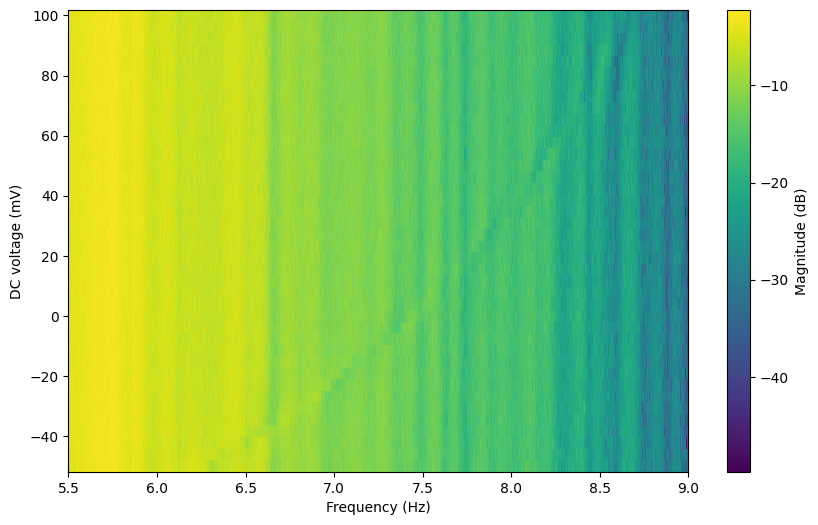

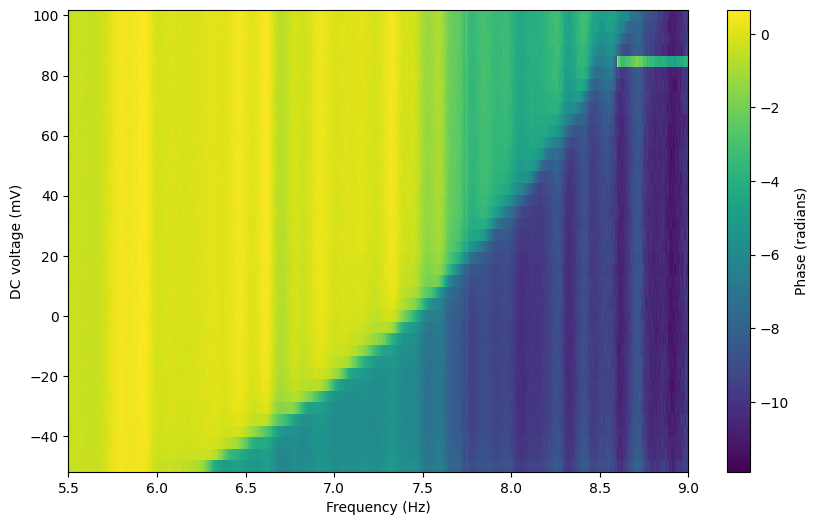

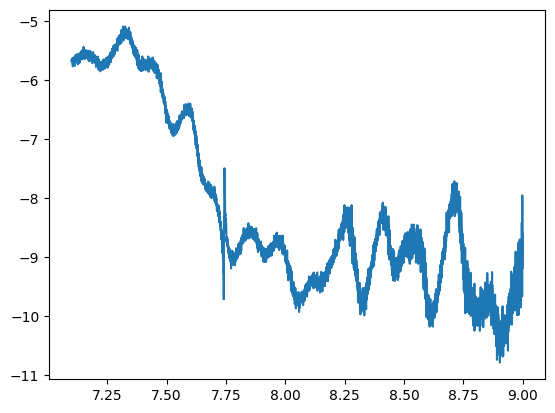

In [63]:
# load data from the pickle file
freq_array, mag_array, phase_array, dc_powers = pickle.load(open('C:/_Data/SMPD/2026_04_30_JPA/JPA_dc_sweep_across_waste.pkl', 'rb'))

# compute the slope of the phase response at 100 mV and from 5.5 to 7.5 GHz, then subtract it from the phase response at all DC powers
dc_power_100mV_idx = np.argmin(abs(dc_powers-100))
freq_zone = (freq_array[dc_power_100mV_idx,:]>5.5)&(freq_array[dc_power_100mV_idx,:]<7.5)
phase_fit = np.polyfit(freq_array[dc_power_100mV_idx,:][freq_zone], phase_array[dc_power_100mV_idx,:][freq_zone], 1)
phase_array = phase_array - np.polyval(phase_fit, freq_array)

# make a heatmap of the magnitude response as a function of frequency and DC power
plt.figure(figsize=(10,6)) 
plt.pcolormesh(freq_array[0,:], dc_powers, mag_array[:,:], shading='auto')
plt.colorbar(label='Magnitude (dB)')
plt.ylabel('DC voltage (mV)')
plt.xlabel('Frequency (Hz)')

plt.figure(figsize=(10,6)) 
plt.pcolormesh(freq_array[0,:], dc_powers, phase_array[:,:], shading='auto')
plt.colorbar(label='Phase (radians)')
plt.ylabel('DC voltage (mV)')
plt.xlabel('Frequency (Hz)')    

plt.figure()
freq_zone = (freq_array[0,:]>7.1)&(freq_array[0,:]<10.8)
plt.plot(freq_array[0,:][freq_zone], phase_array[0,:][freq_zone])

# print out voltages near 20 mV
print('Voltages near 20 mV:')
for i, dc_power in enumerate(dc_powers):
    if abs(dc_power-20) < 10:
        print(dc_power)

The DC voltage at which the resonant frequency is 7.745727 GHz is approximately 18.07 mV.


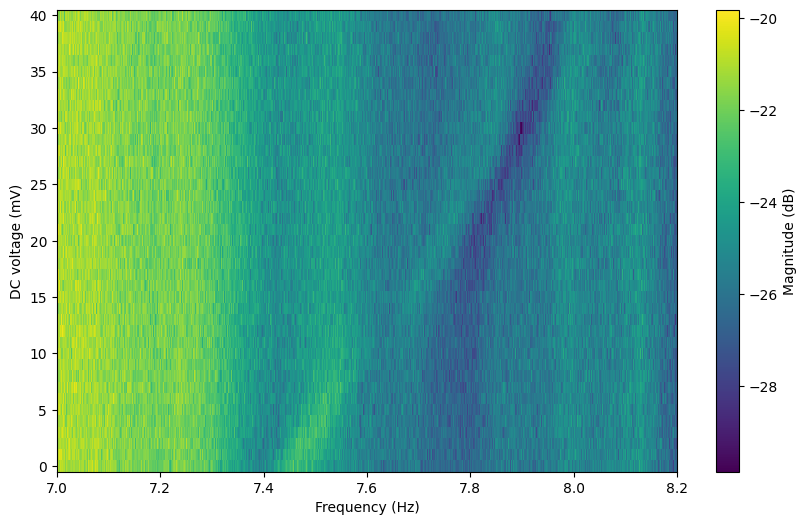

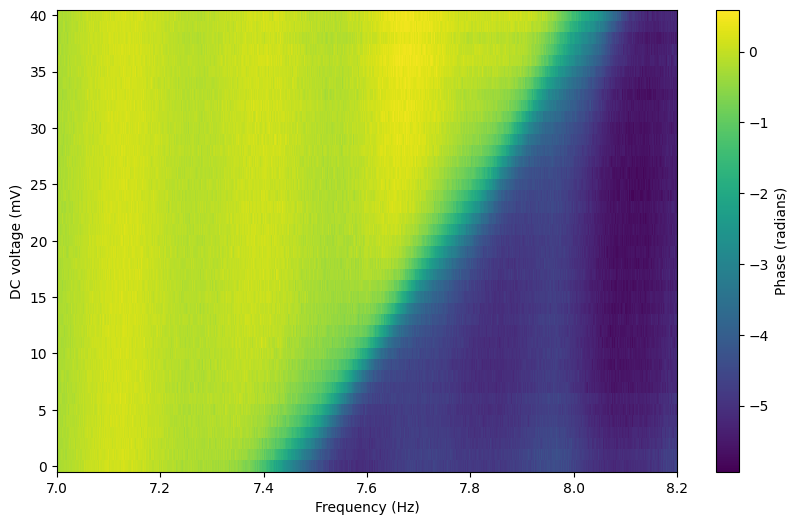

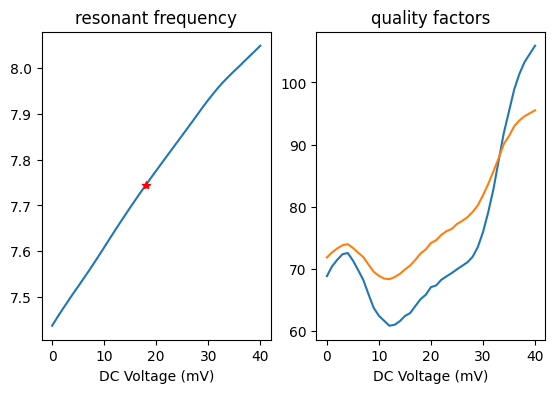

In [79]:
# load data from the pickle file
freq_array, mag_array, phase_array, dc_powers = pickle.load(open('C:/_Data/SMPD/2026_04_30_JPA/JPA_dc_sweep_zoom.pkl', 'rb'))

# compute the slope of the phase response at 40 mV and from 7.0 to 7.6 GHz, then subtract it from the phase response at all DC powers
dc_power_40mV_idx = np.argmin(abs(dc_powers-40))
freq_zone = (freq_array[dc_power_40mV_idx,:]>7.0)&(freq_array[dc_power_40mV_idx,:]<7.6)
phase_fit = np.polyfit(freq_array[dc_power_40mV_idx,:][freq_zone], phase_array[dc_power_40mV_idx,:][freq_zone], 1)
phase_array = phase_array - np.polyval(phase_fit, freq_array)

# make a heatmap of the magnitude response as a function of frequency and DC power
plt.figure(figsize=(10,6)) 
plt.pcolormesh(freq_array[0,:], dc_powers, mag_array[:,:], shading='auto')
plt.colorbar(label='Magnitude (dB)')
plt.ylabel('DC voltage (mV)')
plt.xlabel('Frequency (Hz)')

plt.figure(figsize=(10,6)) 
plt.pcolormesh(freq_array[0,:], dc_powers, phase_array[:,:], shading='auto')
plt.colorbar(label='Phase (radians)')
plt.ylabel('DC voltage (mV)')
plt.xlabel('Frequency (Hz)')    

# at each voltage, convert the phase response to S21 by taking 10^(mag/20)*exp(1j*phase), then fit the data using fitres.fine_fit()
num_dc_powers = len(dc_powers)
frs = np.zeros(num_dc_powers)
Qrs = np.zeros(num_dc_powers)
Qcs = np.zeros(num_dc_powers)
for i in range(len(dc_powers)):
    S21 = 10**(mag_array[i,:]/20) * np.exp(1j*phase_array[i,:])
    

    # compute the derivative of the phase averaged over 200 points, then find the index of the maximum derivative, which is a good initial guess for the resonant frequency
    phase_derivative = np.gradient(phase_array[i,:])
    phase_derivative_avg = np.convolve(phase_derivative, np.ones(200)/200, mode='same')
    max_idx = np.argmax(phase_derivative_avg)

    params = fitres.finefit(freq_array[i,:], S21, [freq_array[i,:][max_idx]])
    frs[i] = params[0]; Qrs[i] = params[1]; Qcs[i] = params[6]*2

    # if fr is more than 0.05 GHz away from the last fr, plot the data and the fit to check if the fit is good
    if i > 0 and abs(frs[i] - frs[i-1]) > 0.05 and not np.isnan(frs[i]) and not np.isnan(frs[i-1]):
        plt.figure(figsize=(10,6))
        plt.plot(S21.real, S21.imag,ls='',marker='.')
        plt.plot(S21.real[max_idx], S21.imag[max_idx], 'ro', label='Initial Guess')

        S21_fit = fitres.resfunc3(freq_array[i,:], *params[:6])
        plt.plot(S21_fit.real, S21_fit.imag)
        plt.xlabel('Frequency (GHz)')
        plt.ylabel('Magnitude (dB)')
        plt.title(f'Fit at DC voltage {dc_powers[i]} mV')
        plt.axis('equal')
        plt.legend()
        plt.grid(True)
        plt.show()

fig,ax = plt.subplots(figsize=(6.5,4),nrows=1,ncols=2)
titles = ['resonant frequency', 'quality factors'] 
ax[0].plot(dc_powers, frs, label='Resonant Frequency (GHz)')
ax[1].plot(dc_powers, Qrs, label='Total Quality Factor')
ax[1].plot(dc_powers, Qcs, label='Coupling Quality Factor')
for i in range(2):
    ax[i].set_xlabel('DC Voltage (mV)')
    # ax[i].set_ylabel('Frequency (GHz) or Quality Factor')
    ax[i].set_title(titles[i])

# interpolate fr vs dc voltage to find the voltage at which fr is at the frequency target
frequency_target = waste_resonance - 7.74 + waste_resonance
from scipy.interpolate import interp1d
fr_interp = interp1d(dc_powers, frs, kind='cubic')
dc_voltage_frequency_target = interp1d(frs, dc_powers, kind='cubic')(frequency_target)
print(f'The DC voltage at which the resonant frequency is {frequency_target:.6f} GHz is approximately {dc_voltage_frequency_target:.2f} mV.')

# put a star at the point where fr is equal to waste_resonance on the plot of fr vs dc voltage
ax[0].plot(dc_voltage_frequency_target, frequency_target, 'r*', label=f'fr = {frequency_target:.6f} GHz')
